# Machine learning and AI for intraday return prediction
We predict the next one minute mid price return of Citigroup (ticker C) for January 2024
with OLS, Random Forest and XGBoost estimated in a walk forward scheme (two week training
window, refitted every trading day). We then backtest each model with transaction costs and
finally add a daily FinBERT news sentiment signal to the Random Forest.

In [1]:
import os
import re
import sys
import time
import urllib.parse
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

## Step 2: Global settings

In [2]:
cmpy = "C"
data_dir = "data"
parquet_path = "data/Trades_Quote.parquet"
output_dir = data_dir
news_cache = os.path.join(data_dir, "news_items_" + cmpy + ".csv")

# Walk forward design: 10 trading days (two weeks) for training, refit before every test day.
# The last val_days of each training window are used only to choose hyperparameters.
train_days = 10
val_days = 2

# Transaction costs: 10 bps for a full round trip, so 5 bps per unit of position change.
cost_round_trip = 0.0010
cost_per_side = cost_round_trip / 2

# Trades whose price deviates from the prevailing mid by more than this share are treated as bad prints.
max_price_dev = 0.01

rv_window = 60
rv_min_periods = 10
target_scale = 1e4
seed = 55
compute_perm_importance = True

target = "NEXT_1MIN_RETURN"

# Variables required by the assignment plus a small set of lagged and intraday seasonality features.
base_features = [
	"ORDER_IMBALANCE",
	"DEPTH_IMBALANCE_AVG",
	"RELATIVE_SPREAD_AVG",
	"TOTAL_TRADED_VOLUME",
	"1MIN_RETURN",
	"REALIZED_VOLAT",
]
extra_features = [
	"RETURN_LAG1",
	"RETURN_5MIN",
	"ORDER_IMBALANCE_5MIN",
	"MINUTE_OF_DAY",
]
features = base_features + extra_features

# Continuous variables that are winsorized at 1% and 99%.
winsor_cols = [
	"ORDER_IMBALANCE",
	"DEPTH_IMBALANCE_AVG",
	"RELATIVE_SPREAD_AVG",
	"TOTAL_TRADED_VOLUME",
	"1MIN_RETURN",
	"REALIZED_VOLAT",
	"RETURN_LAG1",
	"RETURN_5MIN",
	"ORDER_IMBALANCE_5MIN",
]

# News search terms. Generic phrases such as "credit risk" or the bare letter "C" pull in unrelated
# headlines, so every headline must also mention Citi to be kept.
news_keywords = [
	"Citigroup",
	"Citi",
	"Citibank",
	"Citigroup stock",
	"C stock",
	"NYSE:C",
	"Citigroup earnings",
	"Jane Fraser Citi",
]
news_filter = re.compile(r"\bciti", re.IGNORECASE)
news_start = "2024-01-01"
news_end = "2024-02-01"

## Step 3: Data processing
We load the cleaned and merged trades and quotes, remove bad prints, sign trades with the
Lee and Ready algorithm and aggregate to a complete one minute grid for every trading day.

In [3]:
def load_taq(path):
	tq = pd.read_parquet(path)
	tq["TRADE_TIME"] = pd.to_datetime(tq["TRADE_TIME"])
	for col in ["PRICE", "BID", "ASK", "BIDSIZ", "ASKSIZ", "SIZE"]:
		tq[col] = pd.to_numeric(tq[col], errors="coerce").astype(float)
	tq["DATE"] = tq["TRADE_TIME"].dt.normalize()
	tq = tq.sort_values(["COMPANY", "TRADE_TIME"], kind="mergesort").reset_index(drop=True)
	return tq


def clean_taq(tq):
	n_start = len(tq)
	tq = tq.dropna(subset=["PRICE", "BID", "ASK", "SIZE"])
	tq = tq[(tq["BID"] > 0) & (tq["ASK"] > tq["BID"]) & (tq["SIZE"] > 0)].copy()
	tq["MID_PRICE"] = (tq["BID"] + tq["ASK"]) / 2.0
	price_dev = (tq["PRICE"] / tq["MID_PRICE"] - 1).abs()
	tq = tq[price_dev <= max_price_dev]
	minute_of_day = tq["TRADE_TIME"].dt.hour * 60 + tq["TRADE_TIME"].dt.minute
	tq = tq[(minute_of_day >= 570) & (minute_of_day < 960)].copy()
	print("Trades before cleaning:", n_start, "after cleaning:", len(tq), "share removed:", round(1 - len(tq) / n_start, 4))
	return tq.reset_index(drop=True)


def add_trade_variables(tq):
	tq["QUOTED_SPREAD"] = tq["ASK"] - tq["BID"]
	tq["RELATIVE_SPREAD"] = tq["QUOTED_SPREAD"] / tq["MID_PRICE"]
	tq["EFFECTIVE_RELATIVE_SPREAD"] = 2 * (tq["PRICE"] - tq["MID_PRICE"]).abs() / tq["MID_PRICE"]
	depth = (tq["ASKSIZ"] + tq["BIDSIZ"]).replace(0, np.nan)
	tq["DEPTH_IMBALANCE"] = (tq["ASKSIZ"] - tq["BIDSIZ"]) / depth

	# Lee and Ready: quote rule first, tick test for trades exactly at the mid.
	# The original rule only signed trades at or beyond the quotes and ignored all trades inside the spread.
	tick = np.sign(tq.groupby("DATE")["PRICE"].diff()).replace(0, np.nan)
	tick = tick.groupby(tq["DATE"]).ffill()
	quote_sign = np.sign(tq["PRICE"] - tq["MID_PRICE"])
	tq["TRADE_SIGN"] = quote_sign.where(quote_sign != 0, tick).fillna(0)
	tq["BUY_VOLUME"] = np.where(tq["TRADE_SIGN"] > 0, tq["SIZE"], 0.0)
	tq["SELL_VOLUME"] = np.where(tq["TRADE_SIGN"] < 0, tq["SIZE"], 0.0)
	return tq


def aggregate_minutes(tq):
	tq["INTERVAL_TIME"] = tq["TRADE_TIME"].dt.floor("min")
	agg = tq.groupby(["COMPANY", "DATE", "INTERVAL_TIME"]).agg(
		QUOTED_SPREAD_AVG=("QUOTED_SPREAD", "mean"),
		RELATIVE_SPREAD_AVG=("RELATIVE_SPREAD", "mean"),
		EFFECTIVE_RELATIVE_SPREAD_AVG=("EFFECTIVE_RELATIVE_SPREAD", "mean"),
		LAST_MID_PRICE=("MID_PRICE", "last"),
		BID_SIZE_AVG=("BIDSIZ", "mean"),
		ASK_SIZE_AVG=("ASKSIZ", "mean"),
		DEPTH_IMBALANCE_AVG=("DEPTH_IMBALANCE", "mean"),
		BUY_VOLUME_SUM=("BUY_VOLUME", "sum"),
		SELL_VOLUME_SUM=("SELL_VOLUME", "sum"),
		TOTAL_TRADED_VOLUME=("SIZE", "sum"),
		NUM_TRADES=("PRICE", "count"),
	).reset_index()
	agg["ORDER_IMBALANCE"] = (agg["BUY_VOLUME_SUM"] - agg["SELL_VOLUME_SUM"]) / agg["TOTAL_TRADED_VOLUME"].replace(0, np.nan)

	# Reindex every day to the full 09:30 to 15:59 grid so that each return spans exactly one minute.
	zero_cols = ["BUY_VOLUME_SUM", "SELL_VOLUME_SUM", "TOTAL_TRADED_VOLUME", "NUM_TRADES", "ORDER_IMBALANCE"]
	carry_cols = ["QUOTED_SPREAD_AVG", "RELATIVE_SPREAD_AVG", "EFFECTIVE_RELATIVE_SPREAD_AVG", "LAST_MID_PRICE", "BID_SIZE_AVG", "ASK_SIZE_AVG", "DEPTH_IMBALANCE_AVG"]
	frames = []
	for (comp, day), g in agg.groupby(["COMPANY", "DATE"]):
		grid = pd.date_range(day + pd.Timedelta(hours=9, minutes=30), day + pd.Timedelta(hours=15, minutes=59), freq="min")
		g = g.set_index("INTERVAL_TIME").reindex(grid)
		g.index.name = "INTERVAL_TIME"
		g["COMPANY"] = comp
		g["DATE"] = day
		g["MINUTE_HAS_TRADE"] = g["NUM_TRADES"].notna()
		g[zero_cols] = g[zero_cols].fillna(0)
		g[carry_cols] = g[carry_cols].ffill()
		frames.append(g.reset_index())
	minutes = pd.concat(frames, ignore_index=True)
	print("Minute observations:", len(minutes), "minutes without trades:", int((~minutes["MINUTE_HAS_TRADE"]).sum()))
	return minutes


def add_returns_and_features(m):
	m = m.sort_values(["COMPANY", "DATE", "INTERVAL_TIME"]).reset_index(drop=True)
	keys = [m["COMPANY"], m["DATE"]]
	grp = m.groupby(["COMPANY", "DATE"])

	# One minute return from closing mid prices, computed within the day only.
	m["1MIN_RETURN"] = m["LAST_MID_PRICE"] / grp["LAST_MID_PRICE"].shift(1) - 1
	# Target: return over the next minute. The last minute of each day has no target.
	m[target] = m.groupby(["COMPANY", "DATE"])["1MIN_RETURN"].shift(-1)

	# Realized volatility: sum of squared one minute returns over the past hour (raw returns).
	sq = m["1MIN_RETURN"] ** 2
	m["REALIZED_VOLAT"] = sq.groupby(keys).transform(lambda s: s.rolling(rv_window, min_periods=rv_min_periods).sum())

	m["RETURN_LAG1"] = m.groupby(["COMPANY", "DATE"])["1MIN_RETURN"].shift(1)
	m["RETURN_5MIN"] = m["LAST_MID_PRICE"] / grp["LAST_MID_PRICE"].shift(5) - 1
	m["ORDER_IMBALANCE_5MIN"] = m["ORDER_IMBALANCE"].groupby(keys).transform(lambda s: s.rolling(5, min_periods=1).mean())
	m["MINUTE_OF_DAY"] = m["INTERVAL_TIME"].dt.hour * 60 + m["INTERVAL_TIME"].dt.minute - 570
	return m


def winsor_bounds(frame, cols, lower=0.01, upper=0.99):
	return frame[cols].quantile(lower), frame[cols].quantile(upper)


def apply_bounds(frame, cols, lo, hi):
	out = frame.copy()
	out[cols] = out[cols].clip(lower=lo, upper=hi, axis=1)
	return out

In [4]:
tradesquotes = load_taq(parquet_path)
tradesquotes = clean_taq(tradesquotes)
tradesquotes = add_trade_variables(tradesquotes)
minutes = aggregate_minutes(tradesquotes)
minutes = add_returns_and_features(minutes)
trading_days = pd.DatetimeIndex(np.sort(minutes["DATE"].unique()))
print("Trading days:", len(trading_days), "from", trading_days[0].date(), "to", trading_days[-1].date())

Trades before cleaning: 1991986 after cleaning: 1952471 share removed: 0.0198
Minute observations: 8190 minutes without trades: 0
Trading days: 21 from 2024-01-02 to 2024-01-31


Descriptive statistics after winsorizing at 1% and 99% over the full sample. This is for reporting
only. Inside the walk forward loop the winsorization bounds are estimated on each training window
alone, so no information from the test day enters the model.

In [5]:
report_cols = winsor_cols + [target]
lo_all, hi_all = winsor_bounds(minutes, report_cols)
minutes_winsorized = apply_bounds(minutes, report_cols, lo_all, hi_all)
print(minutes_winsorized[report_cols].describe().T)

                       count          mean           std          min          25%           50%           75%            max
ORDER_IMBALANCE       8190.0      0.011562      0.326023    -0.794502    -0.206190      0.008093      0.228832       0.795648
DEPTH_IMBALANCE_AVG   8190.0     -0.022161      0.133094    -0.352370    -0.103440     -0.020419      0.060359       0.315631
RELATIVE_SPREAD_AVG   8190.0      0.000666      0.000754     0.000256     0.000317      0.000365      0.000595       0.004643
TOTAL_TRADED_VOLUME   8190.0  25450.304422  26672.071429  1961.890000  9909.250000  16776.000000  29668.000000  163426.820000
1MIN_RETURN           8169.0      0.000014      0.000914    -0.003669    -0.000372      0.000000      0.000376       0.003846
REALIZED_VOLAT        7980.0      0.000078      0.000089     0.000006     0.000016      0.000042      0.000104       0.000412
RETURN_LAG1           8148.0      0.000013      0.000916    -0.003682    -0.000372      0.000000      0.000376       0

## Step 4: Models and walk forward estimation
Hyperparameters are chosen inside each training window: the model is fitted on the first eight
days and evaluated on the last two, the best setting is then refitted on all ten days.
Random Forest: one minute returns are almost pure noise, so a large min_samples_leaf is essential.
Leaves with 30 observations memorise noise. More trees only reduce variance and never overfit, so
n_estimators = 300 is enough for stable averages. max_features and max_samples decorrelate the trees.
XGBoost: shallow trees, a small learning rate, early stopping on the validation days and a large
min_child_weight (for squared error this equals the minimum number of observations in a leaf).

In [6]:
rf_grid = [{"min_samples_leaf": v} for v in [100, 300, 800]]
xgb_grid = [{"max_depth": d, "min_child_weight": w} for d in [2, 3] for w in [100, 300]]


def build_model(model_name, params, n_estimators=None):
	if model_name == "OLS":
		return make_pipeline(StandardScaler(), LinearRegression())
	if model_name.startswith("RF"):
		return RandomForestRegressor(
			n_estimators=300,
			min_samples_leaf=params["min_samples_leaf"],
			max_features=0.5,
			max_samples=0.7,
			n_jobs=-1,
			random_state=seed,
		)
	return XGBRegressor(
		n_estimators=n_estimators if n_estimators else 600,
		learning_rate=0.02,
		max_depth=params["max_depth"],
		min_child_weight=params["min_child_weight"],
		subsample=0.7,
		colsample_bytree=0.8,
		reg_lambda=5.0,
		objective="reg:squarederror",
		tree_method="hist",
		random_state=seed,
		n_jobs=-1,
	)


def tune_and_fit(model_name, x_train, y_train, train_dates):
	if model_name == "OLS":
		model = build_model("OLS", {})
		model.fit(x_train, y_train)
		return model, {}

	cutoff = np.sort(train_dates.unique())[-val_days]
	is_fit = (train_dates < cutoff).values
	x_fit, y_fit = x_train[is_fit], y_train[is_fit]
	x_val, y_val = x_train[~is_fit], y_train[~is_fit]

	best = None
	if model_name.startswith("RF"):
		for params in rf_grid:
			model = build_model(model_name, params)
			model.fit(x_fit, y_fit)
			score = mean_squared_error(y_val, model.predict(x_val))
			if best is None or score < best[0]:
				best = (score, params)
		params = best[1]
		model = build_model(model_name, params)
		model.fit(x_train, y_train)
		return model, dict(params)

	for params in xgb_grid:
		model = build_model(model_name, params)
		model.set_params(early_stopping_rounds=50)
		model.fit(x_fit, y_fit, eval_set=[(x_val, y_val)], verbose=False)
		score = model.best_score
		n_best = model.best_iteration + 1
		if best is None or score < best[0]:
			best = (score, params, n_best)
	params = dict(best[1])
	params["n_estimators"] = best[2]
	model = build_model(model_name, best[1], n_estimators=best[2])
	model.fit(x_train, y_train, verbose=False)
	return model, params


def native_importance(model_name, model, feats):
	if model_name == "OLS":
		# Absolute standardized coefficients, normalized to sum to one.
		coef = np.abs(model[-1].coef_)
		return pd.Series(coef / coef.sum(), index=feats)
	return pd.Series(model.feature_importances_, index=feats)


def walk_forward(data, feats, model_name):
	days = pd.DatetimeIndex(np.sort(data["DATE"].unique()))
	w_cols = [c for c in feats if c in winsor_cols]
	pred_frames = []
	imp_rows = []
	perm_rows = []
	param_rows = []
	start = time.time()

	for k in range(train_days, len(days)):
		test_day = days[k]
		train = data[data["DATE"].isin(days[k - train_days:k])].dropna(subset=feats + [target])
		test = data[data["DATE"] == test_day].dropna(subset=feats + [target])

		lo, hi = winsor_bounds(train, w_cols)
		x_train = apply_bounds(train[feats], w_cols, lo, hi)
		x_test = apply_bounds(test[feats], w_cols, lo, hi)
		y_lo, y_hi = train[target].quantile(0.01), train[target].quantile(0.99)
		y_train = train[target].clip(y_lo, y_hi) * target_scale

		model, params = tune_and_fit(model_name, x_train, y_train, train["DATE"])

		out = test[["COMPANY", "DATE", "INTERVAL_TIME"]].copy()
		out["y_true_raw"] = test[target].values
		out["y_true"] = test[target].clip(y_lo, y_hi).values
		out["y_pred"] = model.predict(x_test) / target_scale
		pred_frames.append(out)

		imp = native_importance(model_name, model, feats)
		imp["refit_date"] = test_day
		imp_rows.append(imp)
		params["refit_date"] = test_day
		param_rows.append(params)

		if compute_perm_importance:
			# Evaluation only: measured on the test day after the forecasts are made.
			perm = permutation_importance(model, x_test, out["y_true"] * target_scale, scoring="neg_mean_squared_error", n_repeats=5, random_state=seed, n_jobs=1)
			perm_s = pd.Series(perm.importances_mean, index=feats)
			perm_s["refit_date"] = test_day
			perm_rows.append(perm_s)

	print(model_name, "refits:", len(imp_rows), "seconds:", round(time.time() - start, 1))
	res = pd.concat(pred_frames, ignore_index=True)
	return {
		"results": res,
		"importance": pd.DataFrame(imp_rows),
		"perm_importance": pd.DataFrame(perm_rows),
		"params": pd.DataFrame(param_rows),
	}

## Step 5: Forecast evaluation
We report R2 against the sample mean, the out of sample R2 against a zero forecast (the usual
benchmark in return prediction), RMSE, MAE, correlation and sign accuracy. A Diebold and Mariano
test with a Newey and West variance checks whether the squared forecast errors differ from OLS.

In [7]:
def forecast_metrics(res):
	y = res["y_true"].values
	p = res["y_pred"].values
	nonzero = y != 0
	return {
		"R2": r2_score(y, p),
		"R2 oos vs zero": 1 - np.sum((y - p) ** 2) / np.sum(y ** 2),
		"RMSE": np.sqrt(mean_squared_error(y, p)),
		"MAE": mean_absolute_error(y, p),
		"Corr": np.corrcoef(y, p)[0, 1],
		"Sign accuracy": np.mean(np.sign(p[nonzero]) == np.sign(y[nonzero])),
		"Observations": len(y),
	}


def diebold_mariano(res_a, res_b, lags=5):
	both = res_a[["INTERVAL_TIME", "y_true", "y_pred"]].merge(res_b[["INTERVAL_TIME", "y_pred"]], on="INTERVAL_TIME", suffixes=("_a", "_b"))
	d = (both["y_true"] - both["y_pred_a"]) ** 2 - (both["y_true"] - both["y_pred_b"]) ** 2
	d = d.values
	n = len(d)
	dc = d - d.mean()
	lrv = dc @ dc / n
	for lag in range(1, lags + 1):
		lrv += 2 * (1 - lag / (lags + 1)) * (dc[lag:] @ dc[:-lag]) / n
	stat = d.mean() / np.sqrt(lrv / n)
	return stat, 2 * (1 - norm.cdf(abs(stat)))

## Step 6: Backtesting with transaction costs
The position chosen at the close of minute t earns the raw (not winsorized) mid price return from t
to t + 1. Each unit of position change costs 5 bps (10 bps per round trip), and every position is
closed at the end of the day, so no overnight risk is taken.
Rule "quantile" is the original rule: long when the forecast is positive and above the expanding
75th percentile, short when negative and below the 25th percentile.
Rule "cost aware" enters only when the forecast exceeds the one way cost and then holds the position
until the forecast changes sign, which cuts turnover sharply. If this rule never trades, the model
never predicts a one minute return large enough to cover the cost, which is itself an answer to the
question of whether the strategy should be traded.

In [8]:
def positions_quantile(res):
	p = res["y_pred"]
	q25 = p.expanding().quantile(0.25)
	q75 = p.expanding().quantile(0.75)
	return np.where((p > q75) & (p > 0), 1, np.where((p < q25) & (p < 0), -1, 0))


def positions_cost_aware(res, enter=cost_per_side, exit_level=0.0):
	pred = res["y_pred"].values
	day = res["DATE"].values
	pos = np.zeros(len(pred))
	cur = 0
	for i in range(len(pred)):
		if i == 0 or day[i] != day[i - 1]:
			cur = 0
		p = pred[i]
		if cur == 0:
			if p > enter:
				cur = 1
			elif p < -enter:
				cur = -1
		elif cur == 1:
			if p < -enter:
				cur = -1
			elif p <= exit_level:
				cur = 0
		else:
			if p > enter:
				cur = 1
			elif p >= -exit_level:
				cur = 0
		pos[i] = cur
	return pos


def backtest(res, pos):
	bt = res[["DATE", "INTERVAL_TIME", "y_true_raw", "y_pred"]].copy()
	bt["position"] = pos
	prev_pos = bt.groupby("DATE")["position"].shift(1).fillna(0)
	bt["trade"] = (bt["position"] - prev_pos).abs()
	last_of_day = bt["DATE"] != bt["DATE"].shift(-1)
	bt.loc[last_of_day, "trade"] += bt.loc[last_of_day, "position"].abs()
	bt["gross_ret"] = bt["position"] * bt["y_true_raw"]
	bt["net_ret"] = bt["gross_ret"] - cost_per_side * bt["trade"]
	bt["cum_gross"] = (1 + bt["gross_ret"]).cumprod()
	bt["cum_net"] = (1 + bt["net_ret"]).cumprod()
	return bt


def strategy_stats(bt):
	daily = bt.groupby("DATE")["net_ret"].apply(lambda x: (1 + x).prod() - 1)
	n_days = len(daily)
	active = (bt["position"] != 0) & (bt["y_true_raw"] != 0)
	hit = np.mean(np.sign(bt.loc[active, "position"]) == np.sign(bt.loc[active, "y_true_raw"])) if active.any() else np.nan
	drawdown = bt["cum_net"] / bt["cum_net"].cummax() - 1
	std_daily = daily.std()
	std_min = bt["net_ret"].std()
	return {
		"Total net return": bt["cum_net"].iloc[-1] - 1,
		"Total gross return": bt["cum_gross"].iloc[-1] - 1,
		"Avg daily return": daily.mean(),
		"Std daily return": std_daily,
		"Sharpe daily": daily.mean() / std_daily if std_daily > 0 else np.nan,
		"Sharpe annualized": np.sqrt(252) * daily.mean() / std_daily if std_daily > 0 else np.nan,
		"Hit rate": hit,
		"Max drawdown": drawdown.min(),
		"Turnover per minute": bt["trade"].mean(),
		"Turnover per day": bt.groupby("DATE")["trade"].sum().mean(),
		"Time in market": (bt["position"] != 0).mean(),
		"t stat daily": daily.mean() / (std_daily / np.sqrt(n_days)) if std_daily > 0 else np.nan,
		"t stat minute": bt["net_ret"].mean() / (std_min / np.sqrt(len(bt))) if std_min > 0 else np.nan,
	}


def evaluate_model(label, wf):
	res = wf["results"]
	bts = {
		"quantile": backtest(res, positions_quantile(res)),
		"cost aware": backtest(res, positions_cost_aware(res)),
	}
	stats = {rule: strategy_stats(bt) for rule, bt in bts.items()}
	return {"label": label, "forecast": forecast_metrics(res), "backtests": bts, "stats": stats}


def print_importance(label, wf):
	table = pd.DataFrame({
		"native": wf["importance"].drop(columns="refit_date").mean(),
	})
	if len(wf["perm_importance"]):
		table["permutation"] = wf["perm_importance"].drop(columns="refit_date").mean()
	table = table.sort_values("native", ascending=False)
	print("Average feature importance over all refits,", label)
	print(table.round(5))
	return table

## Step 7: OLS benchmark, Random Forest and XGBoost

In [9]:
models = {}
for name in ["OLS", "RF", "XGB"]:
	models[name] = walk_forward(minutes, features, name)

evaluations = {name: evaluate_model(name, wf) for name, wf in models.items()}

OLS refits: 11 seconds: 0.6
RF refits: 11 seconds: 25.2
XGB refits: 11 seconds: 11.6


In [10]:
forecast_table = pd.DataFrame({name: ev["forecast"] for name, ev in evaluations.items()}).T
print("Out of sample forecast metrics")
print(forecast_table.round(6))

for name in ["RF", "XGB"]:
	stat, pval = diebold_mariano(models[name]["results"], models["OLS"]["results"])
	print("Diebold Mariano,", name, "vs OLS, statistic:", round(stat, 3), "p value:", round(pval, 4))

importance_tables = {name: print_importance(name, wf) for name, wf in models.items()}

print("Chosen hyperparameters for each refit, RF")
print(models["RF"]["params"])
print("Chosen hyperparameters for each refit, XGB")
print(models["XGB"]["params"])

Out of sample forecast metrics
           R2  R2 oos vs zero      RMSE       MAE      Corr  Sign accuracy  Observations
OLS  0.071963        0.072151  0.000757  0.000504  0.268527       0.536383        4169.0
RF   0.035185        0.035381  0.000772  0.000504  0.192172       0.528357        4169.0
XGB  0.053098        0.053290  0.000764  0.000505  0.230877       0.527555        4169.0
Diebold Mariano, RF vs OLS, statistic: 3.968 p value: 0.0001
Diebold Mariano, XGB vs OLS, statistic: 2.593 p value: 0.0095
Average feature importance over all refits, OLS
                       native  permutation
1MIN_RETURN           0.51979      8.47019
RETURN_5MIN           0.09466      0.48627
ORDER_IMBALANCE_5MIN  0.08280      0.16454
DEPTH_IMBALANCE_AVG   0.08247      0.18829
ORDER_IMBALANCE       0.07842      0.30173
RETURN_LAG1           0.06469      0.26923
MINUTE_OF_DAY         0.02871     -0.00702
TOTAL_TRADED_VOLUME   0.01679     -0.03426
RELATIVE_SPREAD_AVG   0.01642     -0.00091
REALIZED_VOL

Strategy performance with 10 bps per round trip
                Total net return  Total gross return  Avg daily return  Std daily return  Sharpe daily  Sharpe annualized  Hit rate  Max drawdown  Turnover per minute  Turnover per day  \
OLS quantile            -0.61613             0.55239          -0.08324           0.01539      -5.40753          -85.84187   0.54981      -0.62053              0.67018         254.00000   
    cost aware           0.18495             0.37383           0.01568           0.01730       0.90652           14.39052   0.66207      -0.02840              0.07100          26.90909   
RF  quantile            -0.57547             0.51199          -0.07466           0.02355      -3.17000          -50.32221   0.54419      -0.58226              0.60926         230.90909   
    cost aware           0.00062             0.00866           0.00006           0.00019       0.30151            4.78634   0.57895      -0.00271              0.00384           1.45455   
XGB quantile

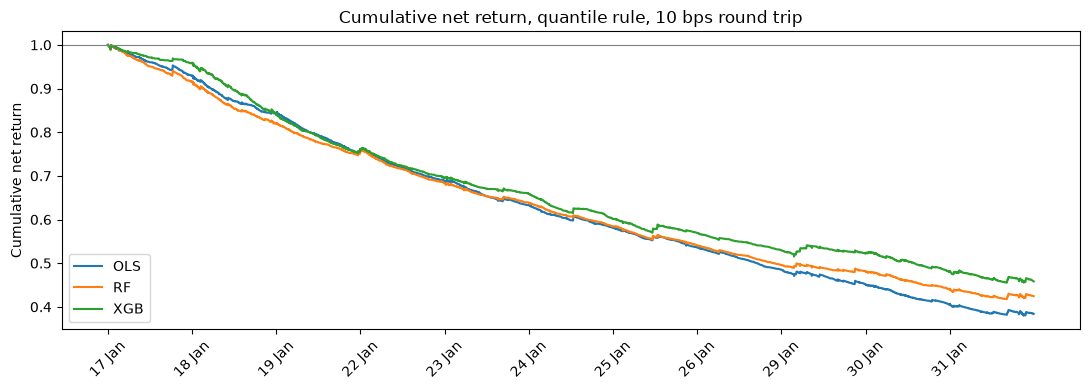

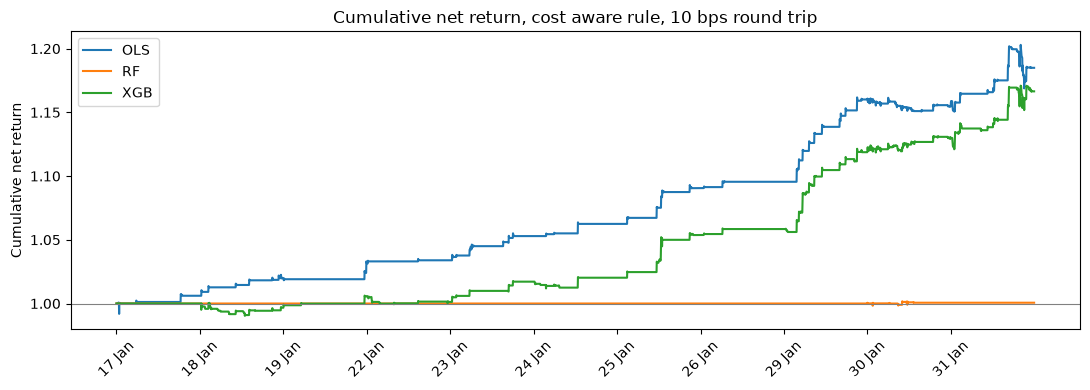

In [11]:
def stats_table(evs):
	rows = {}
	for name, ev in evs.items():
		for rule, st in ev["stats"].items():
			rows[(name, rule)] = st
	return pd.DataFrame(rows).T


strategy_table = stats_table(evaluations)
print("Strategy performance with 10 bps per round trip")
print(strategy_table.round(5))


def plot_cumulative(evs, rule, title, file_name):
	plt.figure(figsize=(11, 4))
	for name, ev in evs.items():
		bt = ev["backtests"][rule]
		plt.plot(np.arange(len(bt)), bt["cum_net"].values, label=name)
	bt0 = next(iter(evs.values()))["backtests"][rule]
	day_starts = np.flatnonzero(bt0["DATE"].values != np.roll(bt0["DATE"].values, 1))
	plt.xticks(day_starts, [pd.Timestamp(d).strftime("%d %b") for d in bt0["DATE"].values[day_starts]], rotation=45)
	plt.axhline(1.0, color="grey", linewidth=0.8)
	plt.title(title)
	plt.ylabel("Cumulative net return")
	plt.legend()
	plt.tight_layout()
	plt.savefig(os.path.join(output_dir, file_name), dpi=150)
	plt.show()


plot_cumulative(evaluations, "quantile", "Cumulative net return, quantile rule, 10 bps round trip", "cum_return_quantile_rule.png")
plot_cumulative(evaluations, "cost aware", "Cumulative net return, cost aware rule, 10 bps round trip", "cum_return_cost_aware_rule.png")

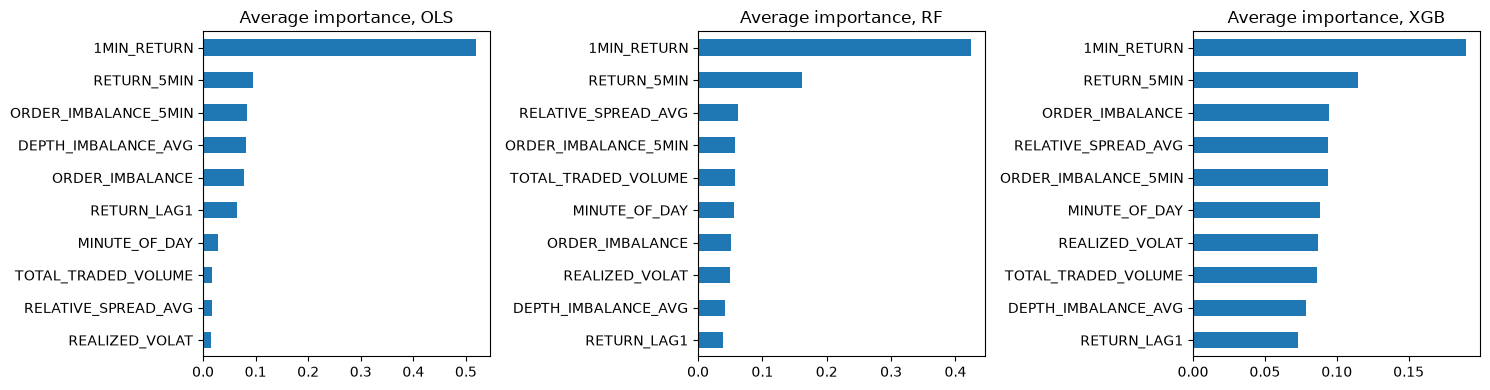

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (name, table) in zip(axes, importance_tables.items()):
	table["native"].sort_values().plot.barh(ax=ax)
	ax.set_title("Average importance, " + name)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "feature_importance.png"), dpi=150)
plt.show()

## Step 8: News sentiment with FinBERT
We scrape Google News RSS with the date operators after: and before: so that the search itself is
restricted to January 2024, keep only headlines that mention Citi and score them with FinBERT.
To avoid look ahead bias each headline is assigned to the first trading day whose 09:30 open comes
after its publication time. News published during trading hours is therefore used from the next day.
Trading days without news receive a neutral signal of 0 instead of being dropped.

In [13]:
def scrape_google_news(keyword):
	import feedparser
	query = '"' + keyword + '" after:' + news_start + " before:" + news_end
	url = "https://news.google.com/rss/search?q=" + urllib.parse.quote_plus(query) + "&hl=en-US&gl=US&ceid=US:en"
	feed = feedparser.parse(url)
	rows = []
	for entry in feed.entries:
		if not getattr(entry, "published_parsed", None):
			continue
		rows.append({
			"keyword": keyword,
			"title": entry.title,
			"timestamp": pd.Timestamp(datetime(*entry.published_parsed[:6]), tz="UTC"),
			"link": entry.link,
		})
	return pd.DataFrame(rows)


def get_news_items():
	frames = []
	for kw in news_keywords:
		try:
			frames.append(scrape_google_news(kw))
			time.sleep(1)
		except Exception as err:
			print("Could not scrape", kw, err)
	news = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

	if len(news) == 0:
		if os.path.exists(news_cache):
			print("Scraping returned nothing, loading cached news from", news_cache)
			news = pd.read_csv(news_cache)
			news["timestamp"] = pd.to_datetime(news["timestamp"], utc=True)
			return news
		return news

	news["headline"] = news["title"].str.rsplit(" - ", n=1).str[0].str.strip()
	ts_et = news["timestamp"].dt.tz_convert("America/New_York")
	in_month = (ts_et >= pd.Timestamp(news_start, tz="America/New_York")) & (ts_et < pd.Timestamp(news_end, tz="America/New_York"))
	news = news[in_month & news["headline"].str.contains(news_filter)]
	news = news.drop_duplicates(subset="headline").sort_values("timestamp").reset_index(drop=True)
	news.to_csv(news_cache, index=False)
	return news


def add_finbert_sentiment(news):
	import torch
	from transformers import pipeline
	device = 0 if torch.cuda.is_available() else -1
	sentiment = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=device)
	# One batched call per headline list, instead of two calls per headline.
	outputs = sentiment(news["headline"].tolist(), batch_size=32, truncation=True)
	news["sentiment_label"] = [o["label"].lower() for o in outputs]
	news["sentiment_score"] = [o["score"] for o in outputs]
	news["sentiment_signal"] = news["sentiment_label"].map({"positive": 1, "neutral": 0, "negative": -1})
	return news


def daily_sentiment(news, days):
	ts_et = news["timestamp"].dt.tz_convert("America/New_York").dt.tz_localize(None)
	open_times = days + pd.Timedelta(hours=9, minutes=30)
	idx = np.searchsorted(open_times.values, ts_et.values, side="left")
	news = news.assign(effective_date=pd.NaT)
	valid = idx < len(days)
	news.loc[valid, "effective_date"] = days[idx[valid]]
	news["effective_date"] = pd.to_datetime(news["effective_date"])
	agg = news.dropna(subset=["effective_date"]).groupby("effective_date").agg(
		sentiment_signal=("sentiment_signal", "mean"),
		news_count=("sentiment_signal", "size"),
	)
	return agg.reindex(days).fillna({"sentiment_signal": 0.0, "news_count": 0})

In [14]:
news_items = get_news_items()
print("Headlines kept:", len(news_items))

sentiment_ready = False
if len(news_items) > 0:
	try:
		if "sentiment_signal" not in news_items.columns:
			news_items = add_finbert_sentiment(news_items)
			news_items.to_csv(news_cache, index=False)
		sentiment_ready = True
	except Exception as err:
		print("FinBERT could not be loaded, sentiment section skipped:", err)

if sentiment_ready:
	print(news_items[["timestamp", "headline", "sentiment_label", "sentiment_score", "sentiment_signal"]].head(10))
	calendar_daily = news_items.groupby(news_items["timestamp"].dt.tz_convert("America/New_York").dt.date)["sentiment_signal"].mean()
	print("Average sentiment signal by calendar day")
	print(calendar_daily)
	sentiment_by_day = daily_sentiment(news_items, trading_days)
	print("Sentiment signal by trading day on which it can first be used")
	print(sentiment_by_day)

Could not scrape Citigroup No module named 'feedparser'
Could not scrape Citi No module named 'feedparser'
Could not scrape Citibank No module named 'feedparser'
Could not scrape Citigroup stock No module named 'feedparser'
Could not scrape C stock No module named 'feedparser'
Could not scrape NYSE:C No module named 'feedparser'
Could not scrape Citigroup earnings No module named 'feedparser'
Could not scrape Jane Fraser Citi No module named 'feedparser'
Headlines kept: 0


## Step 9: Random Forest with the sentiment signal
The signal is constant within a day, so with only 21 trading days the trees can use it to identify
individual days. The comparison below therefore uses the same walk forward design, tuning grid and
trading rules as the model without sentiment, and the Diebold and Mariano test tells us whether any
improvement in forecast errors is statistically meaningful.
Note that the permutation importance of the sentiment signal is always zero, because the signal is
constant within a test day and shuffling it inside that day changes nothing. Its native importance
is the relevant measure here.

In [15]:
if sentiment_ready:
	minutes_sent = minutes.merge(sentiment_by_day, left_on="DATE", right_index=True, how="left")
	minutes_sent["sentiment_signal"] = minutes_sent["sentiment_signal"].fillna(0.0)
	features_sent = features + ["sentiment_signal"]
	models["RF sentiment"] = walk_forward(minutes_sent, features_sent, "RF sentiment")
	evaluations["RF sentiment"] = evaluate_model("RF sentiment", models["RF sentiment"])

	compare = {k: evaluations[k] for k in ["RF", "RF sentiment"]}
	print(pd.DataFrame({k: v["forecast"] for k, v in compare.items()}).T.round(6))
	stat, pval = diebold_mariano(models["RF sentiment"]["results"], models["RF"]["results"])
	print("Diebold Mariano, RF sentiment vs RF, statistic:", round(stat, 3), "p value:", round(pval, 4))
	print_importance("RF sentiment", models["RF sentiment"])
	print(stats_table(compare).round(5))
	plot_cumulative(compare, "quantile", "RF with and without sentiment, quantile rule", "cum_return_rf_sentiment_quantile.png")
	plot_cumulative(compare, "cost aware", "RF with and without sentiment, cost aware rule", "cum_return_rf_sentiment_cost_aware.png")

## Step 10: Summary tables saved to disk

In [16]:
forecast_all = pd.DataFrame({name: ev["forecast"] for name, ev in evaluations.items()}).T
strategy_all = stats_table(evaluations)
forecast_all.to_csv(os.path.join(output_dir, "forecast_metrics.csv"))
strategy_all.to_csv(os.path.join(output_dir, "strategy_metrics.csv"))
for name, wf in models.items():
	wf["results"].to_csv(os.path.join(output_dir, "predictions_" + name.replace(" ", "_") + ".csv"), index=False)
print(forecast_all.round(6))
print(strategy_all.round(5))

           R2  R2 oos vs zero      RMSE       MAE      Corr  Sign accuracy  Observations
OLS  0.071963        0.072151  0.000757  0.000504  0.268527       0.536383        4169.0
RF   0.035185        0.035381  0.000772  0.000504  0.192172       0.528357        4169.0
XGB  0.053098        0.053290  0.000764  0.000505  0.230877       0.527555        4169.0
                Total net return  Total gross return  Avg daily return  Std daily return  Sharpe daily  Sharpe annualized  Hit rate  Max drawdown  Turnover per minute  Turnover per day  \
OLS quantile            -0.61613             0.55239          -0.08324           0.01539      -5.40753          -85.84187   0.54981      -0.62053              0.67018         254.00000   
    cost aware           0.18495             0.37383           0.01568           0.01730       0.90652           14.39052   0.66207      -0.02840              0.07100          26.90909   
RF  quantile            -0.57547             0.51199          -0.07466          